<img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos 2

# Trabajo semanal 0
#### Leandro Robledo



## Introducción
En este Notebook se trabajara sobre el analisis de un filtro activo propuesto por el profesor a modo de comenzar a familiarizarnos con el nuevo entorno de trabajo y la utilizacion de diferentes plataformas como puede ser el LTspcie, Spyder y Jupyter.   


## Actividad
![Esquematico](Esquematico.PNG)

1.  Obtener la función [transferencia](#transferencia) $\frac{V1}{V2} $:  [módulo](#mod) , [fase](#fase) y diagrama de polos y ceros.  

2.  Proponga una [norma](#norma) de frecuencia e impedancia  de forma tal de llegar a una transferencia normalizada

3.  Simule la [transferencia normalizada en Python](#SimNorma).

4. [Simule la red en LTspice](#SimLt) y obtenga su respuesta en frecuencia.

5. [¿ Que tipo de filtro es ?](#analisis) Analizar el caso del MF-103  ¿ Utiliza la misma red ?


+1 💎 Obtener una [red normalizada](#redNorm) que responda a la función hallada en 2 <br>
+1 💎 Verifique los resultados de 1 y 2 mediante el modulo de [simulación simbólica SymPy](#sympy) <br>
+1 💎 Analice similitudes y diferencias con ambas redes del [TP1-Ej7](#ej1.7) ( ex guía anual )



1) <a id="transferencia"></a>
\begin{equation}
\frac{V2-V1}{R2}=\frac{VA-V1}{R1}  \quad ; \quad \quad   (V1-VA)SC1=\frac{VA}{R3}
\end{equation}
\begin{equation}
\frac{V2}{R2}+\frac{V1}{R1}=VA\frac{1}{R1}+\frac{1}{R2} \quad ; \quad V1.SC1=VA.\frac{1+SC1R3}{R3}
\end{equation}
\begin{equation}
VA=V1.\frac{SC1R3}{SC1R3+1}
\end{equation}
\begin{equation}
\frac{V2}{R2}+\frac{V1}{R1}=V1\frac{R1+R2}{R1R2}\frac{SC1R3}{SC1R3+1}
\end{equation}
\begin{equation}
\frac{V2}{R2}=V1[\frac{SC1R3R1+SC1R3R2}{SC1R3R1R2+R1R2}-\frac{1}{R1}]
\end{equation}
\begin{equation}
\frac{V2}{V1}=R2\frac{SC1R1^2 R3+\cancel{SC1R1R2R3}-\cancel{SC1R1R2R3}-R1R2}{SC1R1^2 R2R3+R1^2 R2}
\end{equation}
\begin{equation}
\frac{V2}{V1}=\cancel{\frac{R2R1}{R1R2}}\frac{SC1R1R3-R2}{SC1R1R3+R1}
\end{equation}
\begin{equation}
\frac{V2}{V1}=\frac{S-\frac{R2}{C1R1R3}}{S+\frac{1}{C1R3}}
\end{equation}
\;
\begin{equation}
K=\frac{1}{C1R3}
\end{equation}

### MODULO <a id="mod"></a> 
\begin{equation}
|T(\omega)|=\frac{\sqrt{(\omega)^2+(K\frac{R2}{R1})^2}}{\sqrt{(\omega)^2+K^2}}
\end{equation}
### FASE <a id="fase"></a> 
\begin{equation}
\Theta(\omega)=arctg(\frac{R1\omega}{R2K})-arctg(\frac{\omega}{K})
\end{equation}

In [4]:
# PyTC2: La librería para TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot

from scipy.signal import TransferFunction
import numpy as np
import matplotlib.pyplot as plt


# las librerías que usarremos las cargamos solo una vez.

In [5]:

# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
#
#%%  Inicialización de librerías (esto NO es parte del script demo_seg_orden1.py)
# Setup inline graphics: Esto lo hacemos para que el tamaño de la salida, 
# sea un poco más adecuada al tamaño del jupyter notebook documento

# algún bug cuando lo hice:
plt.figure(1)
plt.close(1)

import matplotlib as mpl

fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 16

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

#%%  Fin - Inicialización de librerías



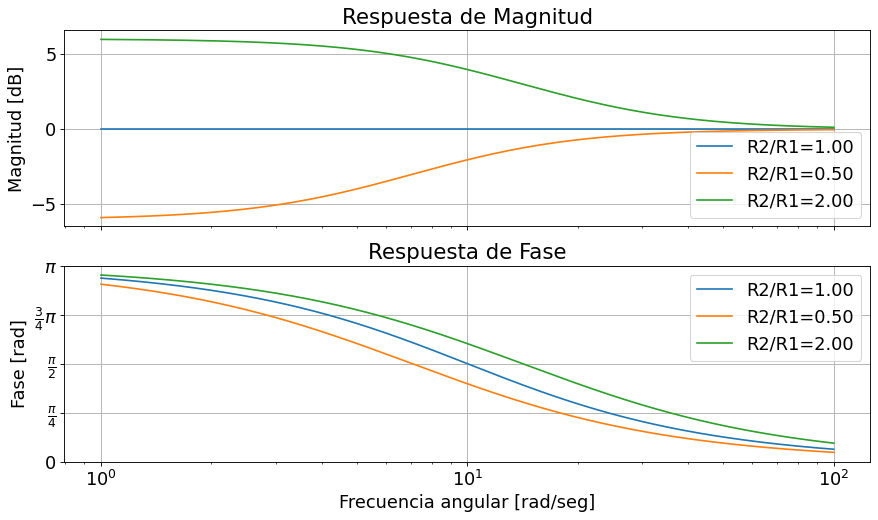

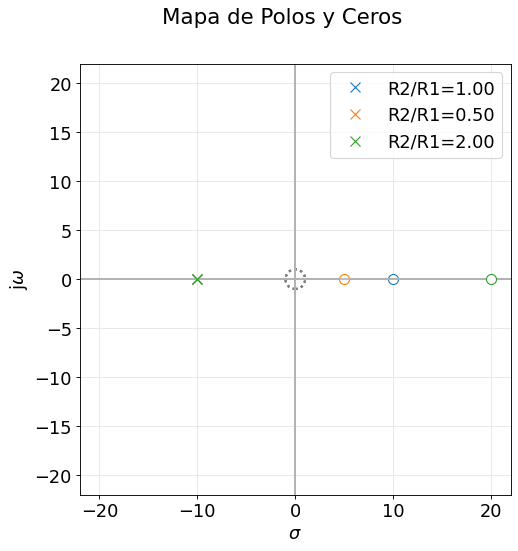

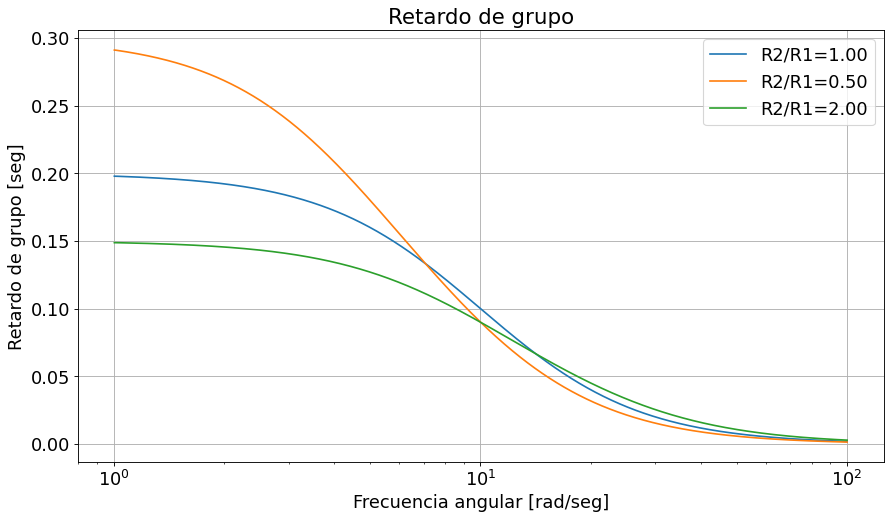

In [11]:
#codigo
#componentes
r1 = 10
r2= 10
r3= 10
c1=1/100
k = 1/(c1*r3)

num = [1, -k*r2/r1]   # s - k*r1
den = [1, k]       # s + k

#my_tf = TransferFunction(num, den)

#plt.close('all')
relaciones = [1, 0.5, 2]

for rel in relaciones:
    
    num = [1, -k*rel]   # s - k*(R2/R1)
    den = [1, k]        # s + k
    
    my_tf = TransferFunction(num, den)
    
    bodePlot(my_tf, fig_id=1, filter_description = 'R2/R1={:3.2f}'.format(rel))

    pzmap(my_tf, fig_id=2, filter_description = 'R2/R1={:3.2f}'.format(rel))
    
    GroupDelay(my_tf, fig_id=3, filter_description = 'R2/R1={:3.2f}'.format(rel))



2- 
## NORMALIZACION EN IMPEDANCIA Y EN FRECIUENCIA <a id="norma"></a>
$$Z_n= R_n, \frac{1}{SC}\quad;\quad Z_n'= \frac{Z_n}{\ohm_Z} \Rightarrow R_n'=\frac{R_n}{\ohm_Z} ,\frac{1}{SC\ohm_Z}$$
Elijo $$\ohm_Z= R3$$
$$R1'=\frac{R1}{R3};R2'=\frac{R2}{R3};R3'=\frac{R3}{R3}=1;C1'=\frac{1}{SC1R3};$$
$$S=S\omega_0; \quad  \omega_0 = \frac{1}{C1R3}= K$$
$$\omega_0 = \frac{1}{C1R3}=1 \Rightarrow \quad C1=\frac{1}{R3}$$
\begin{equation}
T(S\omega_0)=\frac{S\omega_0-\omega_0\frac{R2}{R1}}{S\omega_0+\omega_0}
\end{equation}
\begin{equation}
T(S\omega_0)=\cancel{\frac{\omega_0}{\omega_0}}\frac{S-\frac{R2}{R1}}{S+1}
\end{equation}
\begin{equation}
T(S\omega_0)=\frac{S-\frac{R2}{R1}}{S+1}
\end{equation}

3-A continuacion se Cargara una simulacion con los valores normalizados donde como podemos ver la caida de ganancia del filtro se encuentra en torno a $\omega=1$:
<a id="SimNorma"></a>

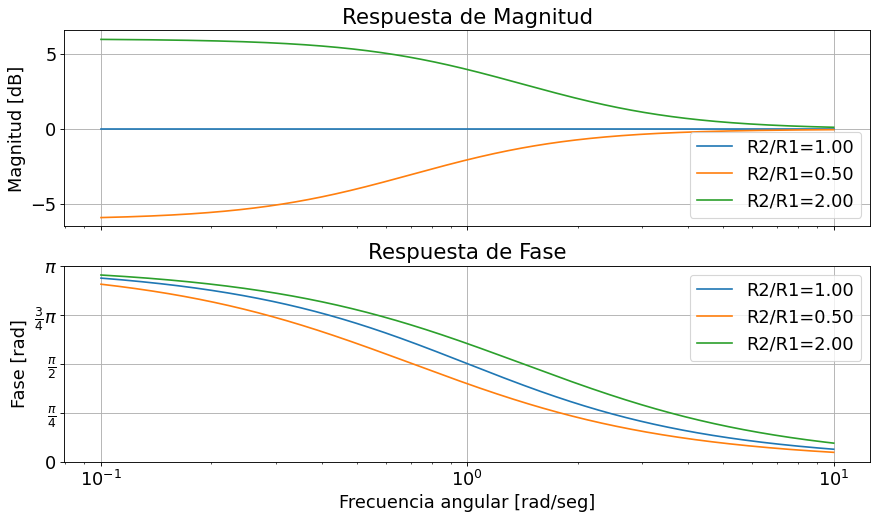

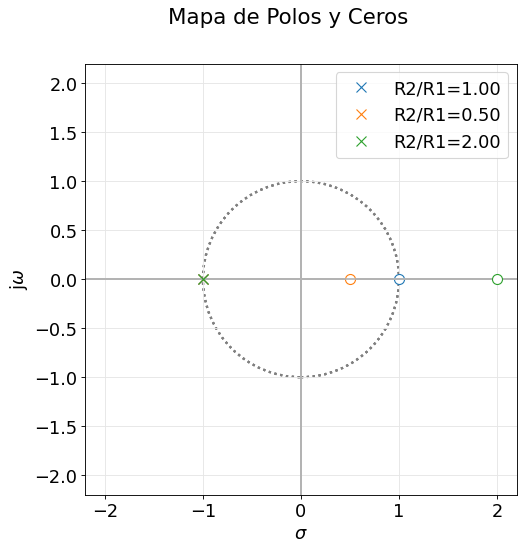

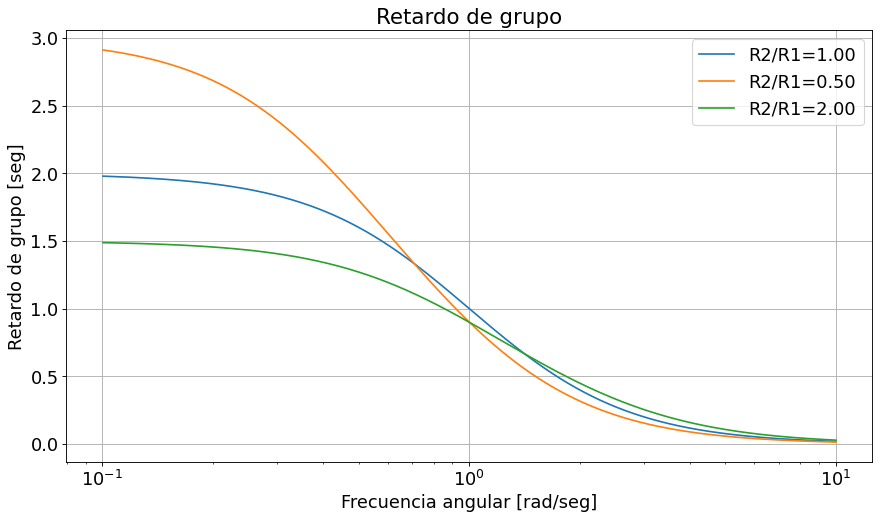

In [13]:
#3-
#codigo
#componentes
r1 = 10
r2= 10
r3= 100
c1=1/100
k = 1/(c1*r3)

num = [1, -k*r2/r1]   # s - k*r1
den = [1, k]       # s + k

#my_tf = TransferFunction(num, den)

#plt.close('all')
relaciones = [1, 0.5, 2]

for rel in relaciones:
    
    num = [1, -k*rel]   # s - k*(R2/R1)
    den = [1, k]        # s + k
    
    my_tf = TransferFunction(num, den)
    
    bodePlot(my_tf, fig_id=1, filter_description = 'R2/R1={:3.2f}'.format(rel))
    
    pzmap(my_tf, fig_id=2, filter_description = 'R2/R1={:3.2f}'.format(rel))
    
    GroupDelay(my_tf, fig_id=3, filter_description = 'R2/R1={:3.2f}'.format(rel))


4-
#### Red simluada en LTspice para R1=R2  <a id="SimLt"></a>
Se puede observar como el filtro funciona como un pasa todo sin ganancia hasta llegar a un poco menos que 1MHz donde la frecuencia de corte del amplificador operacional hace decaer la salida.  
![PTodo](ltspice/PasaTodo_img.PNG)

#### Red simluada en LTspice para R1<R2¶
Por otro lado, cuando la relacion es positiva, es decir R2 mayor que R1, se obtiene una ganancia en el filtro volviendolo un pasa bajos con una frecuencia de corte al rededor de los 100Hz, esta depende de la relacion entre el C1 y la R3.
![PBajo](ltspice/PasaBajo_img.PNG)

#### Red simluada en LTspice para R1>R2¶
Finalmente y algo interesante que tiene este circuito es que cuando la relacion R2/R1 es menor a 1, la salida del filtro se vuelve un pasa alto, deonde no tiene ganancia, y la frecuencia de corte es determinada tambien por C1 y R3.
![PAlto](ltspice/PasaAlto_img.PNG)

Esto nos demuestra la practicidad del filtro ya que poniendo un potenciometro en R2 y R3 podrias tener un pasa todo, pasa bajos con ganancia o un pasa altos con distintas frecuencias de cortes utilizando el mismo circuito, obviamente la simplicidad del circuito recae en que la frecuencia de corte y ganancias sean bastante dispersas. 

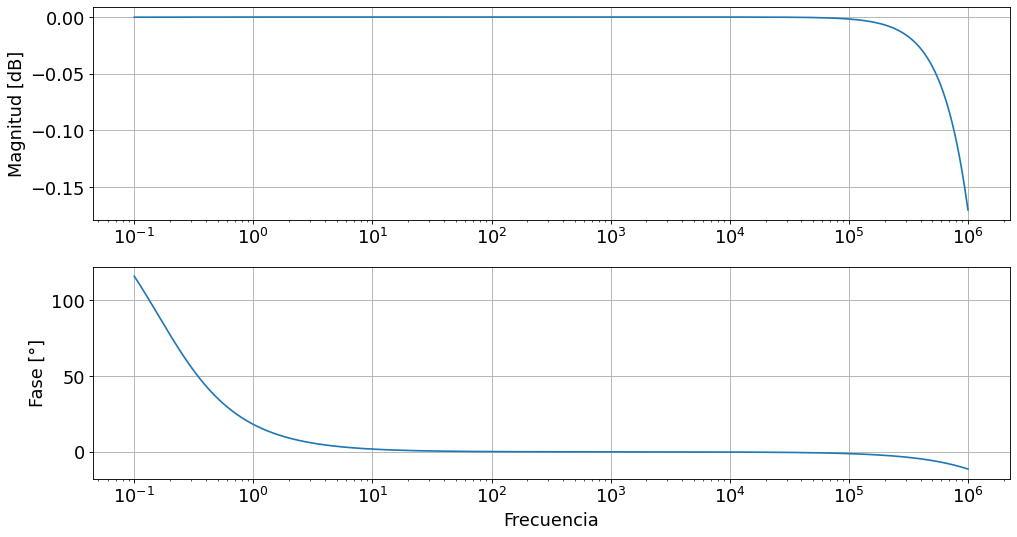

In [14]:
#ploteo de la funcino de transferencia como pasa todo, extraida de LTspice a partir de un .txt
import numpy as np
import matplotlib.pyplot as plt

f = []
mag = []
phase = []

with open('ltspice/PasaTodo_TS0', encoding='latin1') as file:
    next(file)
    
    for line in file:
        parts = line.strip().split('\t')
        
        freq = float(parts[0])
        
        val = parts[1]
        val = val.replace('(', '').replace(')', '')
        val = val.replace('dB', '').replace('°', '')
        
        mag_str, phase_str = val.split(',')
        
        f.append(freq)
        mag.append(float(mag_str))
        phase.append(float(phase_str))

f = np.array(f)
mag = np.array(mag)
phase = np.array(phase)

# 🔥 PLOTS
plt.figure()

# Magnitud
plt.subplot(2,1,1)
plt.semilogx(f, mag)
plt.ylabel('Magnitud [dB]')
plt.grid()

# Fase
plt.subplot(2,1,2)
plt.semilogx(f, phase)
plt.xlabel('Frecuencia')
plt.ylabel('Fase [°]')
plt.grid()

plt.tight_layout()

### 5- Analisis de circuito <a id="analisis"></a>
Como se observo y comento a lo largo del documento, este filtro activo simple de 3 resistencias y un capacitos más un amplificador operacional nos da una funcion de transferencia lineal, y dependiendo de 2 relaciones de los componentes se manejan la ganancia, el tipo de filtro y la frecuencia de corte de estos. <br>
Con R1 y R2 manejamos los primeros dos aspectos. Si R1=R2 funciona como un pasa todo, teniendo la caida en funcion de la frecuencia ocasionada por el amplificador operacional elegido. <br>
R1>R2 se transforma en un pasa altos, el cual no tiene ganancia, y con la relacion entre R3 y C1 determina la frecuencia de corte de este.
Finalmente si R2>R1 el filtro funciona como un pasa bajos con ganancia, y la frecuencia de corte tambien esta delimitada por la R3 y C1<br>
Por ultimo en el analisis del MF_103 lo que pude encontrar que estimo es similar a la red estudiada en este caso es el siguiente circuito:
![Circ_MF](Circuito_MF.PNG)

Sin embargo al simularlo me encuetro con una respuesta en frecuencia distinta a la esperada:
![MF_Simulacion](ltspice/MF.PNG)


### 1.Red normalizada<a id="redNorm"></a>

![R_normalizada](ltspice/Red_Norm.PNG)

### 2. Extra <a id="sympy"></a>

In [7]:
#2
from sympy import Eq
from IPython.display import display
import sympy as sp

s = sp.symbols('s')
R1, R2, R3, C = sp.symbols('R1 R2 R3 C')
V1, V2, Va = sp.symbols('V1 V2 Va')  # Vx = V+ = V-

eq1 = (V2-Va)/R2 + (V1-Va)/R1  
eq2 = (V1-Va)*s*C - (Va)/R3

sol = sp.solve([eq1, eq2], (Va, V2))

T = sp.simplify(sol[V2] / V1)

display(Eq(sp.Function('T')(s), T))

Eq(T(s), (C*R1*R3*s - R2)/(R1*(C*R3*s + 1)))

### 3.Analisis Ej 1-7  <a id="ej1.7"></a>
1.7 El primer circuito es el mismo que la transferencia calculada.

El segundo se trata de una funcion de transferencia de segundo orden que segun la relacion de R1 y R2 funciona como un elimina banda, notch o un pasa todo 
![Transferencia_1_7](Transferencia_ej1-77.jpeg)

Simulado en LTSpcie
![Ej_1_7](ltspice/Ej_1_7.PNG)

In [25]:
# PyTC2: La librería para TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot

from scipy.signal import TransferFunction
import numpy as np
import matplotlib.pyplot as plt

In [26]:
#ploteo
plt.figure(1)
plt.close(1)

import matplotlib as mpl

fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 16

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

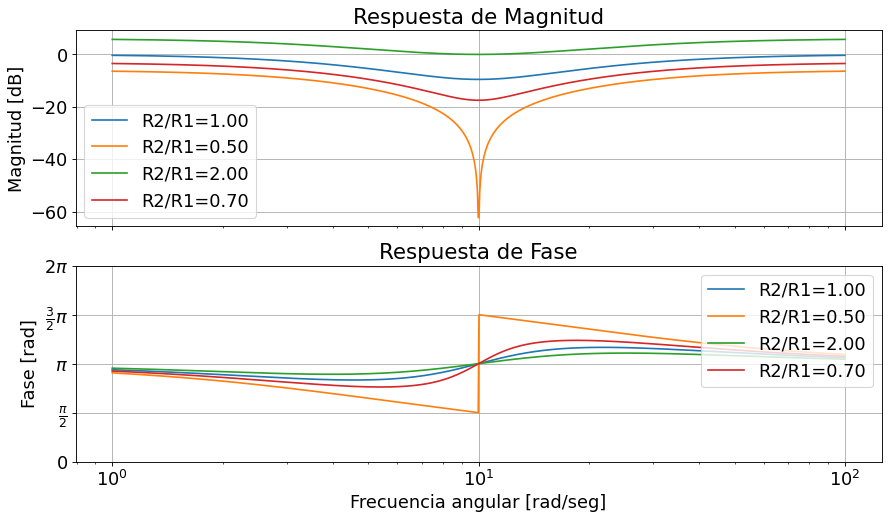

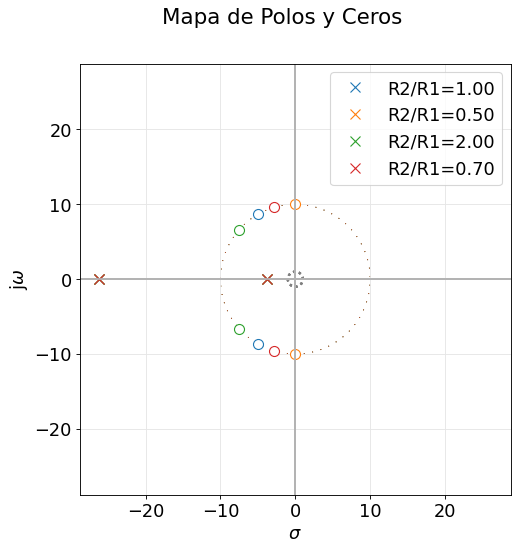

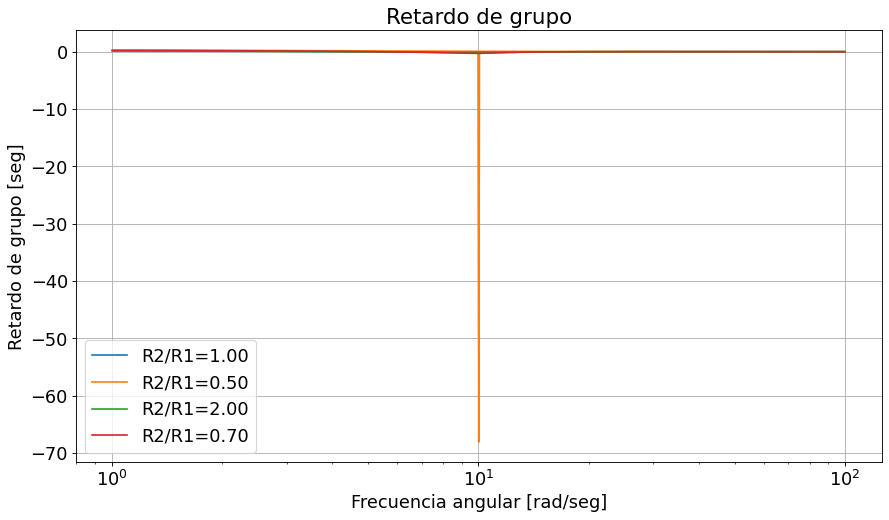

In [27]:
# trasnferencia 1.7
#codigo
#componentes
r = 10
r1= 10
r2= 10
c=1/100
k = 1/(c*r)

num = [-r1/r2, k*(1-2*r2/r1),-k**2*r2/r1]   # -s^2r2/r1 + s k (1-2r2*21) - k^2*r2/r1
den = [1,3*k, k**2]       # s^2 +s 3k+ k^2

my_tf = TransferFunction(num, den)

#plt.close('all')
relaciones = [1, 0.5, 2,0.7]
for rel in relaciones:
    
    num = [-rel, k*(1-2*rel),-k**2*rel]     # -s^2r2/r1 + s k (1-2r2*21) - k^2*r2/r1
    den = [1,3*k, k**2]       # s^2 +s 3k+ k^2
    
    my_tf = TransferFunction(num, den)
    
    bodePlot(my_tf, fig_id=1, filter_description = 'R2/R1={:3.2f}'.format(rel))

    pzmap(my_tf, fig_id=2, filter_description = 'R2/R1={:3.2f}'.format(rel))
    
    GroupDelay(my_tf, fig_id=3, filter_description = 'R2/R1={:3.2f}'.format(rel))